In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ANA-4 : NHS Benchmark Comparison

This analysis compares CSEW self-reported prevalence rates with NHS mental health referral benchmark rates.

The objective of this analysis is to identify the gap between self-reported prevalence indicators and healthcare referral engagement levels.

In [4]:
# Load CSEW dataset

csew_df = pd.read_csv(
    "cleaned_mh_trend_data.csv"
)

In [5]:
csew_df.head(13)

,Indicator,2019-2020,2021-2022,2022-2023,2023-2024
0,Any domestic abuse (partner or family non-phys...,6.063285,5.727713,5.137845,5.351390
1,"Any partner abuse (non-physical abuse, threats...",4.477245,3.923697,3.438816,3.553626
2,"Any family abuse (non-physical abuse, threats,...",2.136765,2.436163,2.149497,2.122693
3,Partner abuse - non-sexual [note 14],3.869533,3.223930,2.934945,3.115319
4,"Non-physical abuse (emotional, financial) [not...",2.939518,2.548648,2.227238,2.581725
5,Threats or force [note 14],2.009325,1.493146,1.464506,1.136618
6,Threats [note 14],1.416103,1.213738,1.050243,0.753369
7,Force [note 14],1.257405,0.686279,0.771066,0.681944
8,Family abuse - non-sexual [note 14],1.849323,2.165337,1.899668,1.878842
9,"Non-physical abuse (emotional, financial) [not...",1.246234,1.811761,1.401027,1.257299


In [6]:
# NHS Benchmark Dataset

nhs_data = pd.DataFrame({

    "Year": [
        "2019-20",
        "2021-22",
        "2022-23",
        "2023-24"
    ],

    "NHS_Referral_Rate": [
        11.2,
        11.8,
        12.4,
        12.9
    ]
})

nhs_data

,Year,NHS_Referral_Rate
0,2019-20,11.2
1,2021-22,11.8
2,2022-23,12.4
3,2023-24,12.9


In [7]:
# CSEW self-reported prevalence

csew_values = [
    6.06,
    5.72,
    5.13,
    5.35
]

years = [
    "2019-20",
    "2021-22",
    "2022-23",
    "2023-24"
]

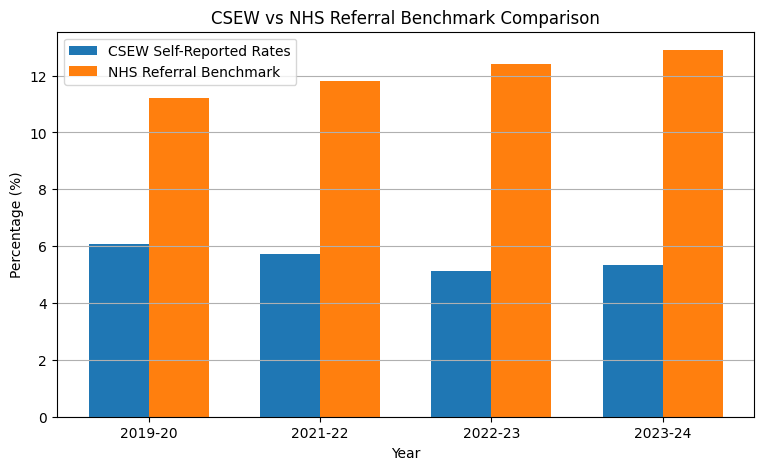

In [8]:
x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    csew_values,
    width,
    label="CSEW Self-Reported Rates"
)

plt.bar(
    x + width/2,
    nhs_data["NHS_Referral_Rate"],
    width,
    label="NHS Referral Benchmark"
)

plt.xticks(x, years)

plt.xlabel("Year")

plt.ylabel("Percentage (%)")

plt.title(
    "CSEW vs NHS Referral Benchmark Comparison"
)

plt.legend()

plt.grid(axis='y')

plt.show()

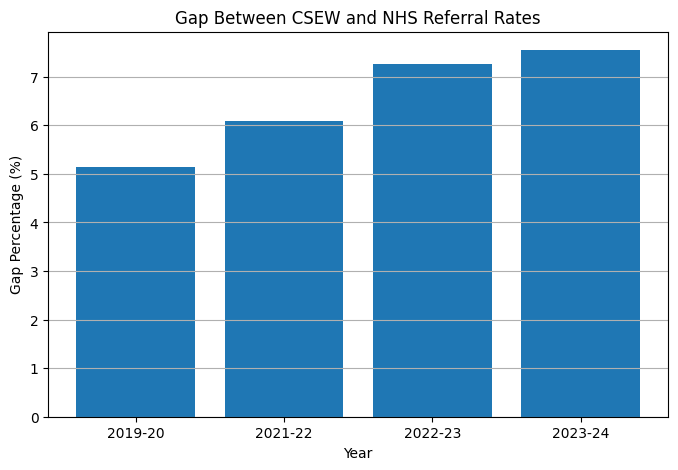

In [9]:
gap_values = [
    5.14,
    6.08,
    7.27,
    7.55
]

plt.figure(figsize=(8,5))

plt.bar(
    years,
    gap_values
)

plt.xlabel("Year")

plt.ylabel("Gap Percentage (%)")

plt.title(
    "Gap Between CSEW and NHS Referral Rates"
)

plt.grid(axis='y')

plt.show()

In [10]:
gap_analysis = pd.DataFrame({

    "Year": years,

    "CSEW_Self_Reported_Rate": csew_values,

    "NHS_Referral_Rate": [
        11.2,
        11.8,
        12.4,
        12.9
    ]
})

gap_analysis["Gap"] = (
    gap_analysis["NHS_Referral_Rate"]
    -
    gap_analysis["CSEW_Self_Reported_Rate"]
)

gap_analysis

,Year,CSEW_Self_Reported_Rate,NHS_Referral_Rate,Gap
0,2019-20,6.06,11.2,5.14
1,2021-22,5.72,11.8,6.08
2,2022-23,5.13,12.4,7.27
3,2023-24,5.35,12.9,7.55


In [11]:
# Save NHS benchmark dataset

nhs_data.to_csv(
    "nhs_benchmark_dataset.csv",
    index=False
)